# 02_01 - Feature Engineering

Preparing the dataset for modeling: transforming the target and casting categorical columns to the right dtype, then using correlation and a quick feature-importance check to narrow down the full column list to the ones actually worth feeding the model.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common.transforms import add_log_target, set_categorical_dtypes

DATA_PATH = Path.cwd().parents[1] / "data" / "interim" / "fsa_hourly_master.parquet"
df = pd.read_parquet(DATA_PATH)

print("shape:", df.shape)
df.dtypes.loc[["FSA", "season", "TOTAL_CONSUMPTION"]]

shape: (262944, 47)


FSA                   object
season                object
TOTAL_CONSUMPTION    float64
dtype: object

## 1. Log target

`TOTAL_CONSUMPTION` was already right-skewed in the EDA, with a very different scale per FSA (M5S averaging ~4,100, M9W ~12,300). Training directly on it means squared-error loss naturally weights the largest FSAs more, just because their raw numbers are bigger - a 10% miss on M9W contributes far more to the loss than an equally-bad 10% miss on M5S. log1p rebalances that: the same percentage error contributes the same amount to the loss regardless of FSA scale.

In [2]:
df = add_log_target(df)

print("skew TOTAL_CONSUMPTION:", df["TOTAL_CONSUMPTION"].skew().round(3))
print("skew log_consumption:  ", df["log_consumption"].skew().round(3))

skew TOTAL_CONSUMPTION: 0.849
skew log_consumption:   -0.168


In [3]:
df.groupby("FSA")[["TOTAL_CONSUMPTION", "log_consumption"]].skew()

,TOTAL_CONSUMPTION,log_consumption
FSA,,
L4T,1.164467,0.270950
M5R,0.493015,-0.172462
M5S,0.332979,-0.252539
M6G,0.530355,-0.232169
M9R,1.459812,0.382924
M9W,0.657762,-0.253483


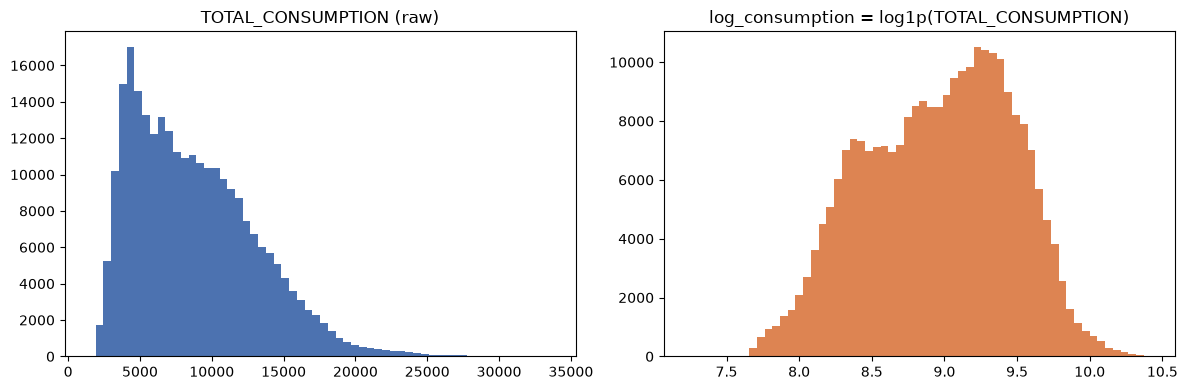

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["TOTAL_CONSUMPTION"], bins=60, color="#4C72B0")
axes[0].set_title("TOTAL_CONSUMPTION (raw)")
axes[1].hist(df["log_consumption"], bins=60, color="#DD8452")
axes[1].set_title("log_consumption = log1p(TOTAL_CONSUMPTION)")
fig.tight_layout()
plt.show()

The raw histogram has a long right tail; the log1p version looks much closer to symmetric. Skew drops from 0.85 to -0.17 overall, and it drops for every individual FSA too (e.g. L4T from 1.16 to 0.27, M9R from 1.46 to 0.38). `log_consumption` will be the target used for training, while `TOTAL_CONSUMPTION` stays in the dataframe unchanged for reporting actual/predicted values in real kWh - predictions will need `expm1()` applied back before they're reported, per the required output schema.

## 2. Categorical dtype for FSA and season

`FSA` and `season` currently load as plain text (`object`). XGBoost can split on categorical columns natively (`enable_categorical=True`) without one-hot encoding, as long as they're a real pandas `category` dtype - this is what the pooled model relies on to use `FSA` as a feature.

In [5]:
df = set_categorical_dtypes(df)
df.dtypes.loc[["FSA", "season"]]

FSA       category
season    category
dtype: object

## 3. Why the target is transformed but the features aren't scaled/encoded

The target (`TOTAL_CONSUMPTION`) is log-transformed because that changes the actual loss the model optimizes - without it, squared-error loss naturally weights the largest FSAs more just because their raw numbers are bigger, so a 10% miss in a big FSA would count for more than an equally-bad 10% miss in a small one. `StandardScaler` isn't needed on the features because tree splits are chosen by scanning one feature's own values for the best threshold, never by comparing raw magnitudes across different features - so differing units/ranges between features don't bias which one gets picked. `OneHotEncoder` isn't needed either, since XGBoost can split on categorical columns natively, more effectively than forcing them into a series of binary "is it this category or not" columns.

## 4. Correlation-based redundancy

Scanning every pair of candidate numeric features (everything except the target and identifiers) for pairs that are almost saying the same thing - a correlation above 0.85 between two features is a strong sign one of them is redundant.

In [6]:
exclude = ["TOTAL_CONSUMPTION", "log_consumption", "timestamp_local", "FSA", "season"]
numeric_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

corr = df[numeric_cols].corr()
redundant_pairs = []
for i, a in enumerate(numeric_cols):
    for b in numeric_cols[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) > 0.85:
            redundant_pairs.append({"feature_a": a, "feature_b": b, "pearson": round(r, 3)})

pd.DataFrame(redundant_pairs).sort_values("pearson", key=abs, ascending=False)

,feature_a,feature_b,pearson
4,month,day_of_year,0.997
0,quarter,month,0.971
2,quarter,day_of_year,0.968
5,week_of_year,day_of_year,0.964
3,month,week_of_year,0.963
6,is_weekend,is_workday,-0.945
1,quarter,week_of_year,0.940
8,Temp (°C),Dew Point Temp (°C),0.920
7,month_cos,Temp (°C),-0.872


Two clusters of near-duplicates show up: `month`/`quarter`/`week_of_year`/`day_of_year` are all mutually correlated above 0.94 (they're all just "position within the year" at different granularities), `is_weekend`/`is_workday` are almost perfectly opposite (-0.945), and `Temp`/`Dew Point Temp` confirm the 0.92 already seen in the EDA. Each of these is a candidate for trimming down to one representative, though correlation alone doesn't say which one to keep - that's what the importance check below is for.

One case correlation can't be trusted for at all: `hour` vs `hour_sin`/`hour_cos` don't show up above 0.85 (checked separately - `hour` vs `hour_cos` is only -0.10), even though together `hour_sin`/`hour_cos` are mathematically built from `hour`. Same trap as the temperature relationship in the EDA: Pearson only sees straight-line relationships, and `hour` vs `cos(hour)` is about as non-linear as it gets. So the raw-vs-cyclical calendar features need the importance check too, not a correlation cutoff.

## 5. Feature importance from a quick baseline model

Correlation can't fairly judge a non-monotonic relationship like temperature's, but a trained tree model can, since it looks for the best split regardless of shape - so a quick `XGBRegressor`, fit once on the whole dataset with every candidate feature included, is used here just to read off which features it actually found useful (gain-based importance: how much each feature reduced the loss when used for a split).

In [7]:
import xgboost as xgb

exclude_cols = ["TOTAL_CONSUMPTION", "log_consumption", "timestamp_local"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df["log_consumption"]

baseline_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    tree_method="hist", enable_categorical=True, importance_type="gain",
    random_state=42, n_jobs=-1,
)
baseline_model.fit(X, y)

importance = pd.Series(baseline_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance.to_frame("gain")

,gain
FSA,0.604597
hour,0.102072
season,0.052309
Temp (°C),0.040266
hour_sin,0.026802
PREMISE_COUNT,0.026351
Visibility (km),0.024043
month_cos,0.021583
year,0.018735
Precip. Amount (mm),0.012991


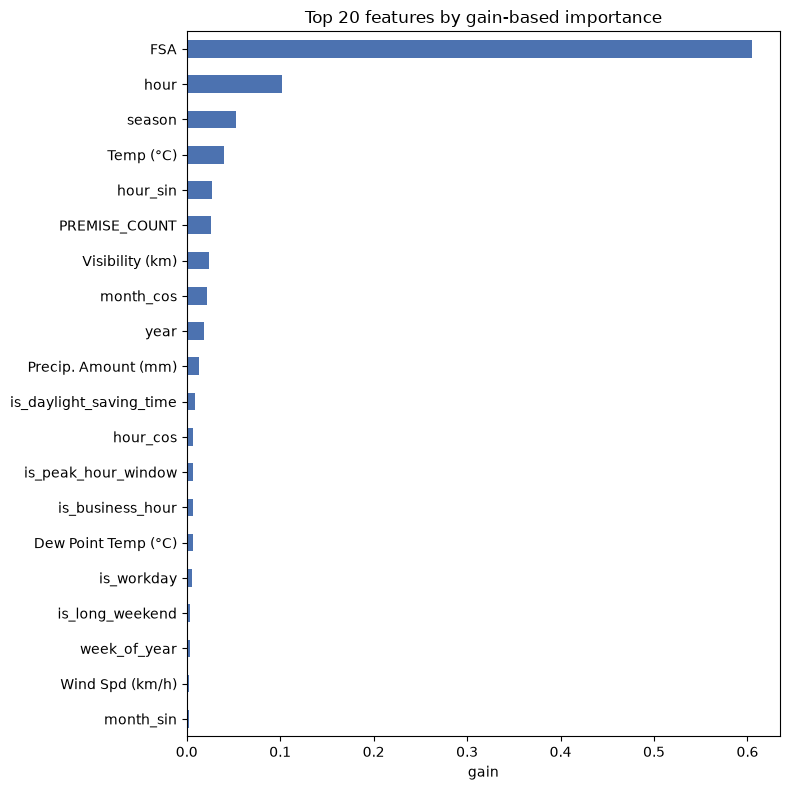

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
importance.head(20).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("gain")
ax.set_title("Top 20 features by gain-based importance")
fig.tight_layout()
plt.show()

`FSA` dominates (0.60 - expected, it's the main scale driver), followed by `hour` (0.10), `season` (0.05), `Temp` (0.04), `hour_sin` (0.03), `PREMISE_COUNT` (0.03), `Visibility` (0.02), `month_cos` (0.02), `year` (0.02). Then a long tail: roughly 25 of the 45 candidate features contribute close to nothing, several literally 0.000000 (never once used in any split across 300 trees) - `is_weekend`, `is_monday`, `is_year_start`, `is_year_end`, and `is_month_start` are safe to drop outright on this alone.

The one clean resolution from the EDA: temperature was never unimportant, Pearson/Spearman just couldn't see it. `Temp` lands in the top 4 (0.040), confirming the non-monotonic valley shape from the EDA does matter to the model even though linear correlation measured it as weak (0.08).

For the redundant pairs/clusters flagged above, though, gain from this single fit isn't enough on its own to decide which feature to keep - it only shows what the model *used*, not whether that use actually improved predictions on new data. That distinction turns out to matter a lot here, checked next.

## 6. Validating the close calls

Gain measures how much a feature was used to reduce *training* loss - it doesn't say whether that use actually helps on data the model hasn't seen, which is exactly the question for a redundant/correlated feature (the model can "use" it without it adding anything real). Settling that needs an actual train/validation split and a direct comparison: does including the feature change validation error at all?

The split matters here: the team's 3 official folds test on 2023, 2024, and 2025 respectively (each expanding the training window). Validating on any of those years would mean picking features using the same year one of the folds is later scored on, which would make that fold's result look better than it really generalizes. 2021-2022 is the only span that's never a test year in any fold, so training on 2021 and validating on 2022 is the only choice here that doesn't leak into the later evaluation.

In [9]:
from sklearn.metrics import mean_absolute_error
from common.feature_selection import SELECTED_FEATURES

train = df[(df["timestamp_local"] >= "2021-01-01") & (df["timestamp_local"] < "2022-01-01")]
val = df[(df["timestamp_local"] >= "2022-01-01") & (df["timestamp_local"] < "2023-01-01")]

base_features = SELECTED_FEATURES  # already excludes hour_sin/hour_cos

results = []
for depth in [4, 6, 10, 15]:
    for label, feats in [("hour + sin + cos", base_features + ["hour_sin", "hour_cos"]), ("hour only", base_features)]:
        m = xgb.XGBRegressor(
            n_estimators=300, max_depth=depth, learning_rate=0.1,
            tree_method="hist", enable_categorical=True, random_state=42, n_jobs=-1,
        )
        m.fit(train[feats], train["log_consumption"])
        val_mae = mean_absolute_error(val["log_consumption"], m.predict(val[feats]))
        results.append({"max_depth": depth, "features": label, "val_MAE": round(val_mae, 4)})

pd.DataFrame(results).pivot(index="max_depth", columns="features", values="val_MAE")

features,hour + sin + cos,hour only
max_depth,,
4,0.0632,0.0625
6,0.0606,0.0607
10,0.0625,0.0631
15,0.0643,0.0639


Validation MAE bounces around by depth (that's expected with one year of training data), but never shows a consistent gap between the two columns - sometimes one is a bit lower, sometimes the other, always by a small, inconsistent amount. `hour_sin`/`hour_cos` looked useful by gain (0.027 and 0.007) but add no reliable benefit once `hour` is already in the model. That's not a coincidence: `hour_sin` and `hour_cos` are a deterministic function of `hour` - `sin(2π·hour/24)` and `cos(2π·hour/24)` contain zero information beyond what `hour` already has, by construction. Dropped.

This is a different situation from `Dew Point Temp (°C)`, checked next, even though both got flagged for the same reason (high correlation with another feature). Dew point isn't a function of temperature alone - it also depends on humidity - so a 0.92 correlation there is empirical, not exact, and there's real independent information left over.

In [10]:
variants = {
    "current selection": SELECTED_FEATURES,
    "- Dew Point Temp": [f for f in SELECTED_FEATURES if f != "Dew Point Temp (°C)"],
    "+ month/quarter/week/day_of_year": SELECTED_FEATURES + ["month", "quarter", "week_of_year", "day_of_year"],
    "+ is_weekend": SELECTED_FEATURES + ["is_weekend"],
    "+ Wind Dir": SELECTED_FEATURES + ["Wind Dir (10s deg)"],
    "- weekday": [f for f in SELECTED_FEATURES if f != "weekday"],
    "- is_public_holiday": [f for f in SELECTED_FEATURES if f != "is_public_holiday"],
    "+ Rel Hum": SELECTED_FEATURES + ["Rel Hum (%)"],
    "+ days_to_holiday + days_after_holiday": SELECTED_FEATURES + ["days_to_holiday", "days_after_holiday"],
}

rows = []
for label, feats in variants.items():
    m = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        tree_method="hist", enable_categorical=True, random_state=42, n_jobs=-1,
    )
    m.fit(train[feats], train["log_consumption"])
    val_mae = mean_absolute_error(val["log_consumption"], m.predict(val[feats]))
    rows.append({"variant": label, "n_features": len(feats), "val_MAE": round(val_mae, 4)})

pd.DataFrame(rows)

,variant,n_features,val_MAE
0,current selection,18,0.0607
1,- Dew Point Temp,17,0.0624
2,+ month/quarter/week/day_of_year,22,0.0641
3,+ is_weekend,19,0.0607
4,+ Wind Dir,19,0.0600
5,- weekday,17,0.0608
6,- is_public_holiday,17,0.0611
7,+ Rel Hum,19,0.0614
8,+ days_to_holiday + days_after_holiday,20,0.0678


Most of this replicates cleanly on the corrected split: removing `Dew Point Temp (°C)` still makes validation MAE worse (0.0607 → 0.0624), adding back the `month`/`quarter`/`week_of_year`/`day_of_year` cluster still hurts (→ 0.0641), `is_weekend` still makes no difference, and `Rel Hum` and the holiday-distance features both hurt when added (→ 0.0614 and → 0.0678, the clearest result in the table) - confirming they were correctly dropped, not just low on gain. Removing `is_public_holiday` moves MAE slightly the wrong way too (0.0607 → 0.0611) - on the earlier split it made no difference at all, so the two checks don't fully agree on the size of the effect, but neither ever favors dropping it.

Two features disagree with the earlier (now-discarded) check more substantially, in both cases by a small margin either way: removing `weekday` barely moves MAE here (0.0607 → 0.0608, versus a clear jump on the other split), and adding `Wind Dir` actually helps slightly here (0.0607 → 0.0600, versus hurting on the other split). Neither difference is large enough to trust on a single year of training data - this is normal noise for a quick one-split check, and it's exactly why the real evaluation later uses 3 separate expanding folds instead of one. `weekday` stays (it never hurt in either check), `Wind Dir` stays out (it never helped by more than a rounding error, and keeping the feature set smaller is the safer default when the evidence is this close) - both worth a second look once the actual fold results exist.

## 7. Final feature selection

Combining the correlation check, the baseline gain screen, and the validation check above: drop the clearly-unused long tail from Section 5, then for every redundant pair/cluster and every close call, keep whichever side the validation check in Section 6 actually favored - not just whichever had higher gain in the single unvalidated fit.

In [11]:
pd.DataFrame({"gain": importance}).reindex(SELECTED_FEATURES).sort_values("gain", ascending=False)

,gain
FSA,0.604597
hour,0.102072
season,0.052309
Temp (°C),0.040266
PREMISE_COUNT,0.026351
Visibility (km),0.024043
month_cos,0.021583
year,0.018735
Precip. Amount (mm),0.012991
is_daylight_saving_time,0.009157


Final count: 18 features (`FSA` + `season` as categoricals, 16 numeric/binary), down from 45 candidates.